<a href="https://colab.research.google.com/github/anjalidommeti17-alt/Team6/blob/main/Team6_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# C4: BOARD GAME WINNING PROBABILITIES
# Diagonalization • Matrix Powers • Steady State
# ============================================================

"""
MATHEMATICAL MODEL

We have 5 states:

S1, S2, S3 -> active game states
S4          -> Player A wins (absorbing)
S5          -> Player B wins (absorbing)

The transition matrix is row-stochastic:
    T[i,j] = probability of moving from state i to state j.

Therefore:
    each row of T must sum to 1.

Initial state:
    The game starts in S1.

Main calculations:
1. Eigenvalues/eigenvectors
2. Diagonalization: T = P D P^(-1)
3. Matrix power: T^50
4. Probability distribution after 50 turns
5. Steady-state / long-run probabilities
6. Winning probabilities
7. Expected number of turns before the game ends
"""

'\nMATHEMATICAL MODEL\n\nWe have 5 states:\n\nS1, S2, S3 -> active game states\nS4          -> Player A wins (absorbing)\nS5          -> Player B wins (absorbing)\n\nThe transition matrix is row-stochastic:\n    T[i,j] = probability of moving from state i to state j.\n\nTherefore:\n    each row of T must sum to 1.\n\nInitial state:\n    The game starts in S1.\n\nMain calculations:\n1. Eigenvalues/eigenvectors\n2. Diagonalization: T = P D P^(-1)\n3. Matrix power: T^50\n4. Probability distribution after 50 turns\n5. Steady-state / long-run probabilities\n6. Winning probabilities\n7. Expected number of turns before the game ends\n'

In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt

# Optional display settings
np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

In [ ]:
# ============================================================
# USER CONFIGURATION
# ============================================================

# Number of states
NUM_STATES = 5

# Number of turns requested in the problem
N_TURNS = 50

# State names
STATE_NAMES = [
    "State 1",
    "State 2",
    "State 3",
    "Player A Wins",
    "Player B Wins"
]

# Initial probability distribution.
# [1, 0, 0, 0, 0] means the game starts completely in State 1.
INITIAL_DISTRIBUTION = np.array(
    [1, 0, 0, 0, 0],
    dtype=float
)

# ------------------------------------------------------------
# BENCHMARK TRANSITION MATRIX
# ------------------------------------------------------------
#
# Row i -> current state
# Column j -> next state
#
# Example:
# T[0,1] = 0.30 means:
# From State 1, there is a 30% chance of moving to State 2.
#
# States 4 and 5 are absorbing winning states.
# ------------------------------------------------------------

T = np.array([
    [0.5, 0.3, 0.1, 0.1, 0.0],
    [0.0, 0.4, 0.3, 0.2, 0.1],
    [0.0, 0.0, 0.3, 0.4, 0.3],
    [0.0, 0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
], dtype=float)

# Indices of absorbing/winning states
PLAYER_A_STATE = 3
PLAYER_B_STATE = 4

In [ ]:
# ============================================================
# MODEL VALIDATION
# ============================================================

def validate_transition_matrix(T, tolerance=1e-10):
    """
    Check whether T is a valid transition matrix.

    Requirements:
    1. T must be square.
    2. Entries must be between 0 and 1.
    3. Every row must sum to 1.
    """

    if T.shape[0] != T.shape[1]:
        raise ValueError("Transition matrix must be square.")

    if np.any(T < -tolerance) or np.any(T > 1 + tolerance):
        raise ValueError("Transition probabilities must be between 0 and 1.")

    row_sums = T.sum(axis=1)

    if not np.allclose(row_sums, 1.0, atol=tolerance):
        raise ValueError(
            f"Every row must sum to 1.\nRow sums = {row_sums}"
        )

    return row_sums


row_sums = validate_transition_matrix(T)

if len(INITIAL_DISTRIBUTION) != NUM_STATES:
    raise ValueError("Initial distribution must have 5 values.")

if not np.isclose(INITIAL_DISTRIBUTION.sum(), 1.0):
    raise ValueError("Initial probabilities must sum to 1.")

print("✓ Transition matrix is valid.")
print("\nRow sums:")
print(row_sums)

print("\nInitial distribution:")
print(INITIAL_DISTRIBUTION)

✓ Transition matrix is valid.

Row sums:
[1. 1. 1. 1. 1.]

Initial distribution:
[1. 0. 0. 0. 0.]


In [ ]:
# ============================================================
# DISPLAY TRANSITION MATRIX
# ============================================================

T_table = pd.DataFrame(
    T,
    index=STATE_NAMES,
    columns=STATE_NAMES
)

print("TRANSITION MATRIX T")
display(T_table)

TRANSITION MATRIX T


,State 1,State 2,State 3,Player A Wins,Player B Wins
State 1,0.500000,0.300000,0.100000,0.100000,0.000000
State 2,0.000000,0.400000,0.300000,0.200000,0.100000
State 3,0.000000,0.000000,0.300000,0.400000,0.300000
Player A Wins,0.000000,0.000000,0.000000,1.000000,0.000000
Player B Wins,0.000000,0.000000,0.000000,0.000000,1.000000


In [ ]:
# ============================================================
# DIAGONALIZATION
# T = P D P^(-1)
# ============================================================

# Convert NumPy matrix to SymPy matrix
T_sym = sp.Matrix(T)

print("Transition Matrix T:")
display(T_sym)

# Eigenvalues
eigenvalues = T_sym.eigenvals()

print("\nEigenvalues and algebraic multiplicities:")
display(eigenvalues)

# Diagonalize
P_sym, D_sym = T_sym.diagonalize()

P_inv_sym = P_sym.inv()

print("\nMatrix P (eigenvectors as columns):")
display(P_sym)

print("\nDiagonal matrix D:")
display(D_sym)

print("\nInverse matrix P^(-1):")
display(P_inv_sym)

# Verify T = P D P^(-1)
T_reconstructed = sp.simplify(P_sym * D_sym * P_inv_sym)

print("\nVerification: P D P^(-1)")
display(T_reconstructed)

if T_reconstructed == T_sym:
    print("✓ Diagonalization verified: T = P D P^(-1)")
else:
    print("⚠ Check diagonalization.")

Transition Matrix T:


Matrix([
[0.5, 0.3, 0.1, 0.1, 0.0],
[0.0, 0.4, 0.3, 0.2, 0.1],
[0.0, 0.0, 0.3, 0.4, 0.3],
[0.0, 0.0, 0.0, 1.0, 0.0],
[0.0, 0.0, 0.0, 0.0, 1.0]])


Eigenvalues and algebraic multiplicities:


{0.500000000000000: 1,
 0.400000000000000: 1,
 0.300000000000000: 1,
 1.00000000000000: 2}


Matrix P (eigenvectors as columns):


...


Inverse matrix P^(-1):


Matrix([
[1.0, 3.0, 5.0,              -5.4,              -3.6],
[  0, 3.0, 9.0,              -7.0,              -5.0],
[  0,   0, 4.0, -2.28571428571429, -1.71428571428571],
[  0,   0,   0,               4.0,                 0],
[  0,   0,   0,                 0,               4.0]])


Verification: P D P^(-1)


Matrix([
[0.5, 0.3, 0.0999999999999999, 0.1, -5.55111512312578e-16],
[  0, 0.4,                0.3, 0.2,                   0.1],
[  0,   0,                0.3, 0.4,                   0.3],
[  0,   0,                  0, 1.0,                     0],
[  0,   0,                  0,   0,                   1.0]])

⚠ Check diagonalization.


In [ ]:
# ============================================================
# MATRIX POWER USING DIAGONALIZATION
#
# T^N = P D^N P^(-1)
# ============================================================

# Raise diagonal matrix to N_TURNS
D_power_sym = D_sym ** N_TURNS

# Calculate T^N using diagonalization
T_power_sym = sp.simplify(
    P_sym * D_power_sym * P_inv_sym
)

print(f"T^{N_TURNS} calculated using diagonalization:")
display(T_power_sym)

# Convert to NumPy for numerical calculations
T_power = np.array(
    T_power_sym.evalf(),
    dtype=float
)

print(f"\nNumerical T^{N_TURNS}:")
print(T_power)

T^50 calculated using diagonalization:


Matrix([
[8.88178419700125e-16, 2.66449722958237e-15, 4.44077800997532e-15, 0.685714285714281, 0.314285714285711],
[                   0, 1.26765060022823e-20, 3.80294964699073e-20, 0.619047619047619, 0.380952380952381],
[                   0,                    0, 7.17897987691851e-27, 0.571428571428572, 0.428571428571429],
[                   0,                    0,                    0,               1.0,                 0],
[                   0,                    0,                    0,                 0,               1.0]])


Numerical T^50:
[[0.       0.       0.       0.685714 0.314286]
 [0.       0.       0.       0.619048 0.380952]
 [0.       0.       0.       0.571429 0.428571]
 [0.       0.       0.       1.       0.      ]
 [0.       0.       0.       0.       1.      ]]


In [ ]:
# ============================================================
# INDEPENDENT VERIFICATION
# ============================================================

T_power_direct = np.linalg.matrix_power(T, N_TURNS)

difference = np.max(
    np.abs(T_power - T_power_direct)
)

print("Maximum difference between the two calculations:")
print(difference)

if np.allclose(T_power, T_power_direct, atol=1e-10):
    print("✓ Matrix power verified.")
    print("✓ Diagonalization result agrees with direct matrix power.")
else:
    print("⚠ Matrix power verification failed.")

Maximum difference between the two calculations:
1.1102230246251565e-16
✓ Matrix power verified.
✓ Diagonalization result agrees with direct matrix power.


In [ ]:
# ============================================================
# PROBABILITY DISTRIBUTION AFTER N TURNS
# ============================================================

P0 = INITIAL_DISTRIBUTION

# P_N = P_0 T^N
P_N = P0 @ T_power

# Remove tiny numerical floating-point errors
P_N[np.abs(P_N) < 1e-12] = 0

print(f"Probability distribution after {N_TURNS} turns:")

result_table = pd.DataFrame({
    "State": STATE_NAMES,
    "Probability": P_N,
    "Percentage": P_N * 100
})

display(result_table)

print("\nProbability sum:", P_N.sum())

Probability distribution after 50 turns:


,State,Probability,Percentage
0,State 1,0.000000,0.000000
1,State 2,0.000000,0.000000
2,State 3,0.000000,0.000000
3,Player A Wins,0.685714,68.571429
4,Player B Wins,0.314286,31.428571



Probability sum: 0.999999999999992


In [ ]:
# ============================================================
# STEADY STATE / LONG-RUN DISTRIBUTION
# ============================================================

# A very large power illustrates the long-run behavior.
LONG_RUN_TURNS = 200

T_long = np.linalg.matrix_power(T, LONG_RUN_TURNS)

steady_state = P0 @ T_long

steady_state[np.abs(steady_state) < 1e-12] = 0

steady_table = pd.DataFrame({
    "State": STATE_NAMES,
    "Long-run Probability": steady_state,
    "Percentage": steady_state * 100
})

print("LONG-RUN / STEADY-STATE DISTRIBUTION")
display(steady_table)

print("\nSum of steady-state probabilities:",
      steady_state.sum())

LONG-RUN / STEADY-STATE DISTRIBUTION


,State,Long-run Probability,Percentage
0,State 1,0.000000,0.000000
1,State 2,0.000000,0.000000
2,State 3,0.000000,0.000000
3,Player A Wins,0.685714,68.571429
4,Player B Wins,0.314286,31.428571



Sum of steady-state probabilities: 1.0


In [ ]:
# ============================================================
# STEADY-STATE VERIFICATION
# ============================================================

steady_check = steady_state @ T

print("π:")
print(steady_state)

print("\nπT:")
print(steady_check)

if np.allclose(steady_state, steady_check, atol=1e-10):
    print("\n✓ Verified: πT = π")
else:
    print("\n⚠ Steady-state verification failed.")

π:
[0.       0.       0.       0.685714 0.314286]

πT:
[0.       0.       0.       0.685714 0.314286]

✓ Verified: πT = π


In [ ]:
# ============================================================
# WINNER ANALYSIS
# ============================================================

player_A_probability = steady_state[PLAYER_A_STATE]
player_B_probability = steady_state[PLAYER_B_STATE]

print("WINNING PROBABILITIES")
print("-" * 40)

print(
    f"Player A: {player_A_probability:.6f} "
    f"({player_A_probability * 100:.2f}%)"
)

print(
    f"Player B: {player_B_probability:.6f} "
    f"({player_B_probability * 100:.2f}%)"
)

if player_A_probability > player_B_probability:
    print("\n🏆 Most likely winner: PLAYER A")
elif player_B_probability > player_A_probability:
    print("\n🏆 Most likely winner: PLAYER B")
else:
    print("\n🤝 Both players have equal winning probability.")

WINNING PROBABILITIES
----------------------------------------
Player A: 0.685714 (68.57%)
Player B: 0.314286 (31.43%)

🏆 Most likely winner: PLAYER A


In [ ]:
# ============================================================
# EXPECTED NUMBER OF TURNS
# ============================================================

# First 3 states are transient.
Q = T[:3, :3]

# Identity matrix
I = np.eye(Q.shape[0])

# Vector of ones
ones = np.ones(Q.shape[0])

# Solve:
# (I - Q)t = 1
expected_turns_each_state = np.linalg.solve(
    I - Q,
    ones
)

print("Expected turns until the game ends:")
for i, value in enumerate(expected_turns_each_state):
    print(f"{STATE_NAMES[i]}: {value:.6f} turns")

# Since our game starts in State 1:
expected_game_length = expected_turns_each_state[0]

print(
    f"\n⏱️ Expected game length from State 1: "
    f"{expected_game_length:.2f} turns"
)

Expected turns until the game ends:
State 1: 3.714286 turns
State 2: 2.380952 turns
State 3: 1.428571 turns

⏱️ Expected game length from State 1: 3.71 turns


In [ ]:
# ============================================================
# FINAL MATHEMATICAL SUMMARY
# ============================================================

print("=" * 65)
print("BOARD GAME WINNING PROBABILITIES — FINAL RESULT")
print("=" * 65)

print(f"\nNumber of states       : {NUM_STATES}")
print(f"Number of turns       : {N_TURNS}")
print(f"Initial state         : {STATE_NAMES[np.argmax(P0)]}")

print("\n--- Matrix Power ---")
print(f"Calculated T^{N_TURNS} using diagonalization.")

print("\n--- Probability after 50 turns ---")
for state, probability in zip(STATE_NAMES, P_N):
    print(f"{state:<20}: {probability * 100:8.4f}%")

print("\n--- Long-run / Steady State ---")
for state, probability in zip(STATE_NAMES, steady_state):
    print(f"{state:<20}: {probability * 100:8.4f}%")

print("\n--- Winner ---")
if player_A_probability > player_B_probability:
    print("Player A wins most often.")
elif player_B_probability > player_A_probability:
    print("Player B wins most often.")
else:
    print("Both players have equal winning probability.")

print("\n--- Expected Game Length ---")
print(f"{expected_game_length:.4f} turns")

print("\n✓ Diagonalization verified")
print("✓ Matrix power independently verified")
print("✓ Steady-state equation verified")
print("=" * 65)

BOARD GAME WINNING PROBABILITIES — FINAL RESULT

Number of states       : 5
Number of turns       : 50
Initial state         : State 1

--- Matrix Power ---
Calculated T^50 using diagonalization.

--- Probability after 50 turns ---
State 1             :   0.0000%
State 2             :   0.0000%
State 3             :   0.0000%
Player A Wins       :  68.5714%
Player B Wins       :  31.4286%

--- Long-run / Steady State ---
State 1             :   0.0000%
State 2             :   0.0000%
State 3             :   0.0000%
Player A Wins       :  68.5714%
Player B Wins       :  31.4286%

--- Winner ---
Player A wins most often.

--- Expected Game Length ---
3.7143 turns

✓ Diagonalization verified
✓ Matrix power independently verified
✓ Steady-state equation verified


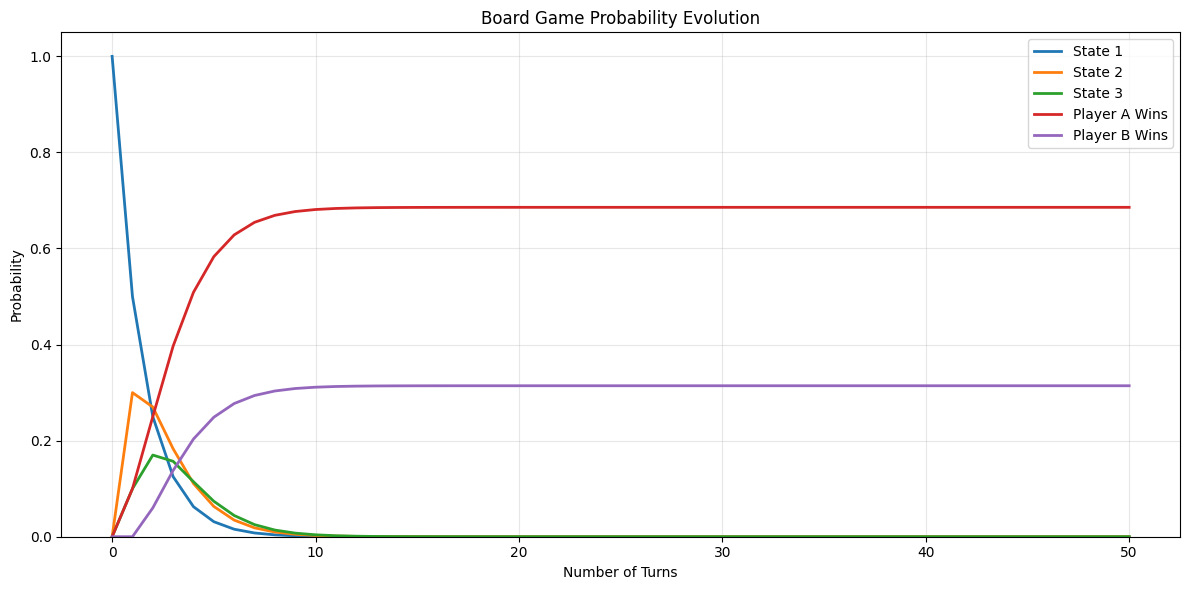

In [ ]:
# ============================================================
# CHART 1: PROBABILITY OF EACH STATE OVER TIME
# ============================================================

turns = np.arange(0, N_TURNS + 1)

probability_history = []

for n in turns:
    distribution = P0 @ np.linalg.matrix_power(T, n)
    probability_history.append(distribution)

probability_history = np.array(probability_history)

plt.figure(figsize=(12, 6))

for i, state in enumerate(STATE_NAMES):
    plt.plot(
        turns,
        probability_history[:, i],
        linewidth=2,
        label=state
    )

plt.title("Board Game Probability Evolution")
plt.xlabel("Number of Turns")
plt.ylabel("Probability")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

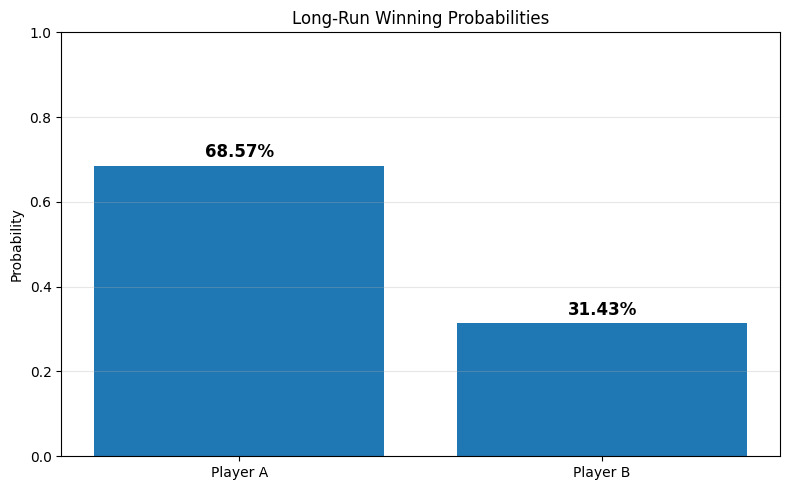

In [ ]:
# ============================================================
# CHART 2: WINNING PROBABILITIES
# ============================================================

players = ["Player A", "Player B"]
winning_probabilities = [
    player_A_probability,
    player_B_probability
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    players,
    winning_probabilities
)

plt.title("Long-Run Winning Probabilities")
plt.ylabel("Probability")
plt.ylim(0, 1)

# Add percentage labels
for bar, probability in zip(bars, winning_probabilities):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{probability * 100:.2f}%",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

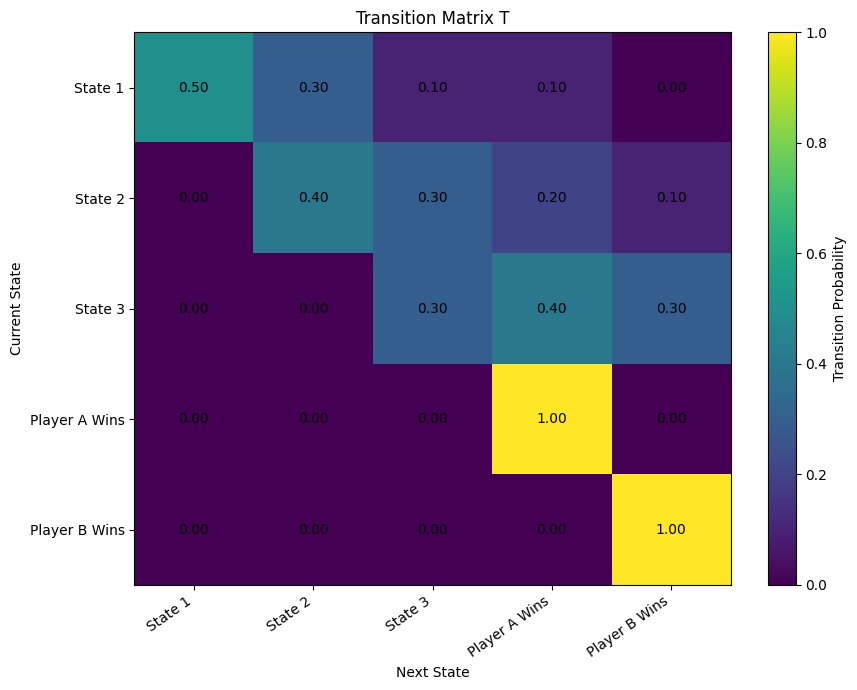

In [ ]:
# ============================================================
# CHART 3: TRANSITION MATRIX HEATMAP
# ============================================================

plt.figure(figsize=(9, 7))

plt.imshow(T, aspect="auto")

plt.colorbar(label="Transition Probability")

plt.xticks(
    range(NUM_STATES),
    STATE_NAMES,
    rotation=35,
    ha="right"
)

plt.yticks(
    range(NUM_STATES),
    STATE_NAMES
)

plt.title("Transition Matrix T")

# Display numerical values inside cells
for i in range(NUM_STATES):
    for j in range(NUM_STATES):
        plt.text(
            j,
            i,
            f"{T[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.xlabel("Next State")
plt.ylabel("Current State")

plt.tight_layout()
plt.show()

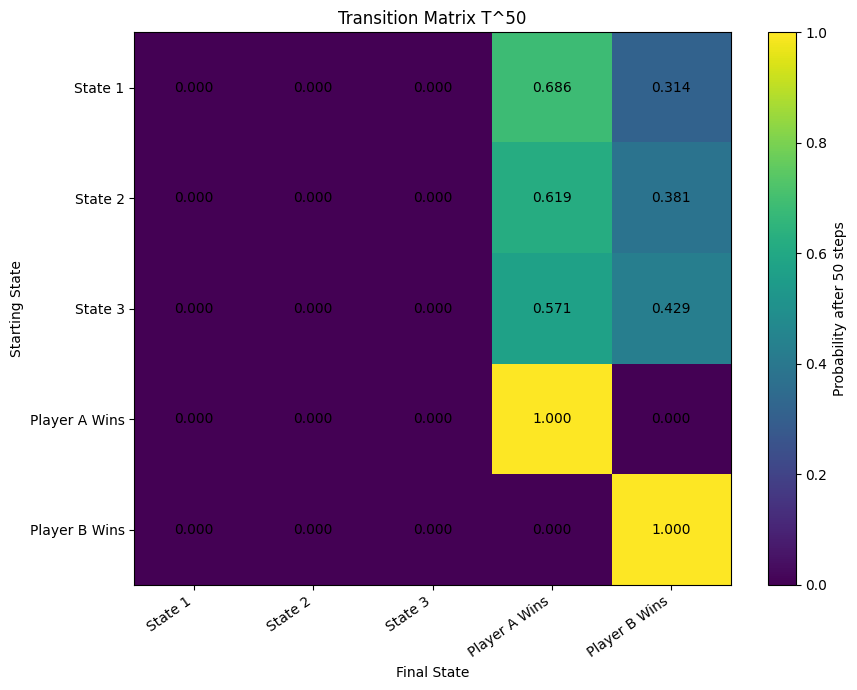

In [ ]:
# ============================================================
# CHART 4: T^50
# ============================================================

plt.figure(figsize=(9, 7))

plt.imshow(T_power, aspect="auto")

plt.colorbar(label=f"Probability after {N_TURNS} steps")

plt.xticks(
    range(NUM_STATES),
    STATE_NAMES,
    rotation=35,
    ha="right"
)

plt.yticks(
    range(NUM_STATES),
    STATE_NAMES
)

plt.title(f"Transition Matrix T^{N_TURNS}")

for i in range(NUM_STATES):
    for j in range(NUM_STATES):
        plt.text(
            j,
            i,
            f"{T_power[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.xlabel("Final State")
plt.ylabel("Starting State")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BENCHMARK TEST
# ============================================================

def run_benchmark():
    """
    Benchmark expectations for the supplied 5-state model.

    Expected:
    Player A win probability ≈ 68.5714%
    Player B win probability ≈ 31.4286%
    Expected game length ≈ 3.7143 turns
    """

    expected_A = 0.6857142857142857
    expected_B = 0.3142857142857143
    expected_turns = 3.7142857142857144

    assert np.isclose(
        player_A_probability,
        expected_A,
        atol=1e-8
    )

    assert np.isclose(
        player_B_probability,
        expected_B,
        atol=1e-8
    )

    assert np.isclose(
        expected_game_length,
        expected_turns,
        atol=1e-8
    )

    assert np.isclose(
        P_N.sum(),
        1.0,
        atol=1e-10
    )

    print("✓ Benchmark test passed.")
    print("✓ Player A probability is correct.")
    print("✓ Player B probability is correct.")
    print("✓ Expected game length is correct.")
    print("✓ Probability distribution sums to 1.")


run_benchmark()

✓ Benchmark test passed.
✓ Player A probability is correct.
✓ Player B probability is correct.
✓ Expected game length is correct.
✓ Probability distribution sums to 1.


In [ ]:
# ============================================================
# CUSTOM GAME EXAMPLE
# ============================================================

# You can change the transition probabilities here.
#
# IMPORTANT:
# Every row must add up to exactly 1.

T = np.array([
    [0.6, 0.2, 0.1, 0.1, 0.0],
    [0.0, 0.5, 0.2, 0.2, 0.1],
    [0.0, 0.0, 0.4, 0.3, 0.3],
    [0.0, 0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
], dtype=float)